In [2]:
# QC all subjects


import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from itertools import compress
from utils.gao_functions import calculate_vtc, calculate_aprime, get_image_cat
import mne
import matplotlib.pyplot as plt

experiment_name = 'GAO'


subs = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29']#
# subs = ['26']


# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal



figdir = '/Users/annacorriveau/Documents/GitHub/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}


gao_folder = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/'


In [6]:
# How many trials removed for each participant?
prop_dropped = []
for sub in subs:
    eeg_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'
    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    # print(len(artifacts))
    # print(sum(artifacts))
    # print(sum(artifacts)/len(artifacts))
    prop_dropped.append(sum(artifacts)/len(artifacts))

print(np.mean(prop_dropped))
print(np.std(prop_dropped))


0.2688103448275862
0.1501510014163005


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

0.05140345076172896
0.05909256401758137
0.05101376202245117
0.04883439089050293
0.04027440160643847
0.02558854806534358
0.03933335494049396
0.016489553002222213


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

0.057764507662611486
0.06831165493280811
0.06655773281292443
0.061104929360226906
0.05597331404309902
0.033192936012317015
0.04736459951375313
0.056745103853583334


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

...

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

0.06044233508052224
0.0804289353104509
0.05889523509068807
0.07894383986595749
0.03527355453587794
0.02400005737569766
0.027069136059925322
0.019078290443914667


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

0.043264362645848986
0.03594535923576063
0.04614677745896849
0.03714170891140964
mean= 0.9268714709937893
STD= 0.032441605853850836
29
0


(array([2., 2., 0., 1., 3., 2., 8., 2., 4., 5.]),
 array([0.85307961, 0.86483001, 0.87658041, 0.88833081, 0.90008121,
        0.91183161, 0.92358201, 0.93533241, 0.94708281, 0.95883321,
        0.97058361]),
 <BarContainer object of 10 artists>)

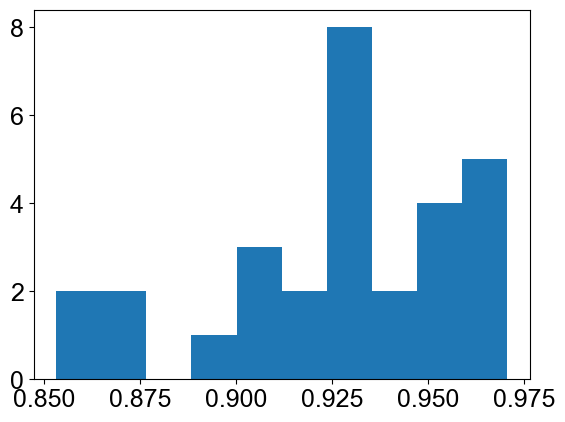

In [2]:
# Step 1: calculate A' across all participants

FWHM = 4
aprime = []



for sub in subs:
    behav_dir =  gao_folder + 'data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir = gao_folder + 'data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'


    behav_files = glob.glob(behav_dir + sub + '*.csv')
    # print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_vtc(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    # cpt_trials_vtc.to_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC.csv')
    # print(cpt_trials_vtc)

    # print(cpt_trials_vtc['accuracy'].shape)
    cpt_trials_vtc['hit'] = np.where(((cpt_trials_vtc['accuracy']==1) & (cpt_trials_vtc['correct_response']==1)),1,0)
    cpt_trials_vtc['miss'] = np.where(((cpt_trials_vtc['accuracy']==0) & (cpt_trials_vtc['correct_response']==1)),1,0)
    cpt_trials_vtc['FA'] = np.where(((cpt_trials_vtc['accuracy']==0) & (cpt_trials_vtc['correct_response']==0)),1,0)
    cpt_trials_vtc['CR'] = np.where(((cpt_trials_vtc['accuracy']==1) & (cpt_trials_vtc['correct_response']==0)),1,0)

    # print(np.sum(cpt_trials_vtc['FA']) + np.sum(cpt_trials_vtc['CR']))

    
    h = np.nansum(cpt_trials_vtc['hit'])    / (np.nansum(cpt_trials_vtc['hit']) + np.nansum(cpt_trials_vtc['miss']))
    fa = np.nansum(cpt_trials_vtc['FA'])    / (np.nansum(cpt_trials_vtc['FA']) + np.nansum(cpt_trials_vtc['CR']))

    aprime.append(calculate_aprime(h,fa))


print(f'mean= {np.mean(aprime)}')
print(f'STD= {np.std(aprime)}')

print(len(aprime))

mask_exclude_aprime = aprime < (np.mean(aprime) - (2.5*np.std(aprime)))
print(np.sum(mask_exclude_aprime))


plt.hist(aprime)

In [3]:
# Step 2: count how many trials included after preprocessing--


# FWHM = 9
n_train_images = []
n_test_images = []
n_train_gabors = []
n_test_gabors = []

for sub in subs:
    behav_dir =  gao_folder + 'data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir = gao_folder + 'data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'


    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_vtc(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    # cpt_trials_vtc.to_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC.csv')


    # Load preprocessed EEG data--remove artifacts
    epochs = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]


    x_data = epochs.get_data(picks='eeg')

    x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    x_data_pupil = epochs.get_data(picks=['pupil'])
    x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    # included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    # included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    n_train_images.append(np.sum(y_train_image==11) + np.sum(y_train_image==12))
    n_train_gabors.append(np.sum(y_train_gabor==21) + np.sum(y_train_gabor==22))
    n_test_images.append(np.sum(y_test_image==31) + np.sum(y_test_image==32))
    n_test_gabors.append(np.sum(y_test_gabor==41) + np.sum(y_test_gabor==42))


    

n_train_full = np.array(n_train_gabors) + np.array(n_train_images)
# print(n_test_full)
print(n_train_full<(810 *2))
print(list(compress(subs, n_train_full<(810 *2))))

n_test_full = np.array(n_test_gabors) + np.array(n_test_images)
# print(n_test_full)
print(n_test_full<(540 *2))
print(list(compress(subs, n_test_full<(540 *2))))




exclude_subs = set(list(compress(subs, n_train_full<(810 *2))) + list(compress(subs, n_test_full<(540 *2)))) 

include_subs = list(set(subs) - exclude_subs)
print(sorted(include_subs))

with open("included_subs.py", "w") as f:
    f.write("subs = " + str(sorted(include_subs)))

['/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896
0.05909256401758137
0.05101376202245117
0.04883439089050293
Reading /Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False False False]
Dropped 1240 epochs: 2, 8, 10, 16, 23, 37, 39, 45, 46, 52, 60, 61, 70, 78, 91, 94, 95, 100, 108, 113, 124, 125, 133, 134, 137, 148, 149, 161, 166, 167, 168, 187, 199, 200, 212, 213, 226, 229, 239, 248, 252, 253, 255, 267, 277, 281, 288, 290, 295, 303, 306, 311, 314, 322, 326, 331, 333, 336, 338, 344, 348, 350, 352, 358, 364, 367, 371, 377, 379, 380, 384, 392, 399, 403, 411, 416, 417, 421, 426, 431, 438, 444, 454, 458, 464, 468, 476, 478, 482, 490, 495, 502, 507, 508, 514, 516, 520, 525, 532, 537, 541, 547, 548, 551, 553, 558, 563, 565, 569, 576, 580, 586, 587, 591, 595, 615, 627, 631, 651, 662, 669, 678, 693, 696, 709, 724, 742, 752, 772, 781, 788, 790, 791, 799, 814, 822, 823, 824, 833, 838, 854, 888, 891, 895

...

0.02400005737569766
0.027069136059925322
0.019078290443914667
Reading /Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-28/eeg/sub-28_task-GAO_desc-preprocessed_eeg.fif ...


/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['vtc_lower_quartile_detrended'] = np.quantile(sub_run_df['vtc_detrended'], 0.25)
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['vtc_smooth_upper_quartil

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False False ... False False  True]
Dropped 595 epochs: 7, 29, 30, 38, 64, 69, 76, 92, 93, 94, 101, 116, 118, 121, 127, 135, 146, 149, 152, 164, 168, 179, 180, 190, 212, 222, 230, 234, 253, 260, 262, 269, 283, 285, 286, 307, 310, 313, 339, 348, 352, 356, 361, 364, 366, 383, 399, 402, 403, 404, 416, 426, 430, 443, 446, 462, 483, 489, 498, 505, 523, 529, 549, 568, 577, 583, 596, 612, 618, 623, 624, 636, 642, 644, 649, 653, 661, 664, 669, 679, 680, 685, 715, 726, 742, 743, 746, 756, 758, 762, 771, 787, 804, 823, 824, 833, 846, 849, 859, 863, 865, 867, 877, 883, 894, 920, 921, 924, 929, 931, 938, 958, 983, 989, 1000, 1007, 1013, 1017, 1019, 1044, 1056, 1064, 1066, 1071, 1079, 1084, 1093, 1094, 1106, 1108, 1112, 1114, 1115, 1117, 1118, 1121, 1134, 114

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["detrended_RT"] = sub_run_df["rt"]-(intercept+slope*np.arange(len(sub_run_df))) #subtract linear trend
/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df["me

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False False ... False False False]
Dropped 1595 epochs: 5, 6, 14, 19, 20, 29, 32, 38, 40, 41, 42, 43, 49, 50, 51, 52, 53, 55, 56, 58, 60, 63, 66, 68, 69, 75, 82, 88, 90, 93, 104, 112, 113, 124, 128, 136, 146, 154, 164, 165, 176, 191, 203, 206, 208, 218, 219, 220, 227, 232, 234, 242, 243, 250, 254, 264, 273, 278, 285, 291, 298, 310, 311, 320, 321, 331, 336, 337, 342, 347, 351, 357, 358, 364, 365, 366, 373, 377, 391, 394, 395, 401, 414, 422, 436, 437, 446, 453, 464, 466, 469, 476, 484, 485, 486, 490, 494, 499, 507, 509, 511, 512, 518, 519, 527, 534, 542, 551, 552, 555, 556, 563, 572, 575, 579, 580, 581, 588, 589, 594, 600, 604, 615, 626, 627, 632, 633, 645, 650, 657, 659, 670, 676, 687, 691, 700, 701, 705, 709, 712, 717, 725, 728, 729, 734, 737, 7